#**[Wildfire Prediction using Time Series Analysis](https://www.sciencebuddies.org/)**

This notebook was developed by Science Buddies [www.sciencebuddies.org](https://www.sciencebuddies.org/) as part of a science project to allow students to explore and learn about artificial intelligence. For personal use, this notebook can be downloaded and modified with attribution. For all other uses, please see our [Terms and Conditions of Fair Use](https://www.sciencebuddies.org/about/terms-and-conditions-of-fair-use).  

**Troubleshooting tips**
*   Read the written instructions at Science Buddies and the text and comments on this page carefully.
*   If you make changes that break the code, you can download a fresh copy of this notebook and start over.

*   If you are using this notebook for a science project and need help, visit our [Ask an Expert](https://www.sciencebuddies.org/science-fair-projects/ask-an-expert-intro) forum for assistance.

## **How To Use This Notebook**

This notebook contains text fields, like this one, that give you information about the project and instructions.

In [471]:
# There are also code blocks, like this one.

# The green text in a code block are comments. Comments are descriptions of what the code does.

# The non-green text in a code block is the Python code. Click on the triangle in the top left corner to run this code block.

print("Congratulations, you ran a code block! Try changing the text in the code and running it again.")

Congratulations, you ran a code block! Try changing the text in the code and running it again.


# Importing Libraries

In [472]:
# Install Prophet for forecasting and the Holidays package (v0.28) for holiday features
# !pip install prophet holidays==0.28

In [473]:
# --- Core libraries ---
import warnings                       # To handle warning messages
import glob                           # For working with file paths/patterns

# --- Data manipulation ---
import pandas as pd                   # Data analysis and manipulation
import numpy as np                    # Numerical computations

# --- Visualization ---
import matplotlib.pyplot as plt       # Plotting
import matplotlib.colors as mcolors   # Advanced color handling for matplotlib
import seaborn as sns                 # Statistical plotting (built on matplotlib)
import folium                         # Interactive maps
import branca.colormap as cm          # Colormaps for Folium visualizations

# --- Machine learning / forecasting ---
from prophet import Prophet           # Time series forecasting
from sklearn.metrics import mean_absolute_error  # Model evaluation metric

# --- Pandas extensions ---
from pandas.api.types import CategoricalDtype    # Handling categorical dtypes

# --- Global settings ---
warnings.filterwarnings("ignore")     # Suppress warnings
plt.style.use('ggplot')               # Set plot style
plt.style.use('fivethirtyeight')      # Override with another style

# --- Custom utility functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error (MAPE) given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [445]:
# Import Google Colab's drive module to access Google Drive files
#from google.colab import drive

# Mount Google Drive to the Colab environment at the given path (/content/drive)
# After running this, you'll be prompted to authorize access to your Google Drive
#drive.mount('/content/drive')

# Loading the Data into a Pandas DataFrame

Code Block 1A

In [476]:
# Path to the folder containing wildfire CSV files on Google Drive
csv_path = "../data/NASA-MODIS-DATA/"

# Find all CSV files in the specified folder and store their file paths in a list
csv_files = glob.glob(csv_path + "*.csv")

# Read each CSV file into a Pandas DataFrame and store all DataFrames in a list
dfs = [pd.read_csv(f) for f in csv_files]

# Concatenate all DataFrames into a single DataFrame, resetting the row index
df = pd.concat(dfs, ignore_index=True)

# Convert the 'acq_date' column to datetime format for easier date operations
df['acq_date'] = pd.to_datetime(df['acq_date'])

# Set 'acq_date' as the index of the DataFrame for time series handling
df.set_index('acq_date', inplace=True)

# Sort the DataFrame by date (index) in ascending order
df.sort_index(inplace=True)

# Save the combined, sorted DataFrame to a new CSV file in the same folder
df.to_csv(csv_path + "combined-countries.csv")
df.to_csv(csv_path + "df_2019_2024.csv")

Code Block 1B

In [447]:
# Define the path to the project folder stored in Google Drive
csv_path = "../data/NASA-MODIS-DATA/"

# Load the dataset (CSV file) into a pandas DataFrame
# In this case, we are reading "df_2019_2024.csv" from the specified folder
df = pd.read_csv(csv_path + "df_2019_2024.csv")

# Convert the 'acq_date' column to datetime objects and set it as the index
df['acq_date'] = pd.to_datetime(df['acq_date'])
df.set_index('acq_date', inplace=True)

df.head()

,latitude,longitude,brightness,scan,track,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
acq_date,,,,,,,,,,,,,,
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2


# Visualizing the Data

Code Block 2A

In [448]:
def plot_frp_by_timeframe(df, year, month=None):
    """
    Generates a line plot of Fire Radiative Power (FRP) for a specific year and optional month,
    or a bar graph of monthly median FRP for a specific year.

    Args:
        df (pd.DataFrame): The input DataFrame with a datetime index.
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). If None, a bar graph
                               of monthly median FRP for the year is generated.
    """
    if month is not None:
        df_filtered = df[(df.index.year == year) & (df.index.month == month)].copy()
        timeframe_str = f"Fire Radiative Power (FRP) for {month}/{year}"
        plot_type = 'line'
    else:
        df_filtered = df[df.index.year == year].copy()
        timeframe_str = f"Monthly Median Fire Radiative Power (FRP) for {year}"
        plot_type = 'bar'

    if df_filtered.empty:
        print(f"No data found for {timeframe_str.replace('Monthly Median ', '')}")
        return

    plt.figure(figsize=(12, 6))

    if plot_type == 'line':
        plt.plot(df_filtered.index, df_filtered['frp'])
        plt.xlabel('Date')
        plt.ylabel('FRP')
    elif plot_type == 'bar':
        # Group by month and calculate the mean FRP
        monthly_frp = df_filtered.resample('M')['frp'].mean()
        monthly_frp.index = monthly_frp.index.strftime('%Y-%m') # Format for x-axis
        monthly_frp.plot(kind='bar')
        plt.xlabel('Month')
        plt.ylabel('Median FRP')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    plt.title(timeframe_str)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

Code Block 2B

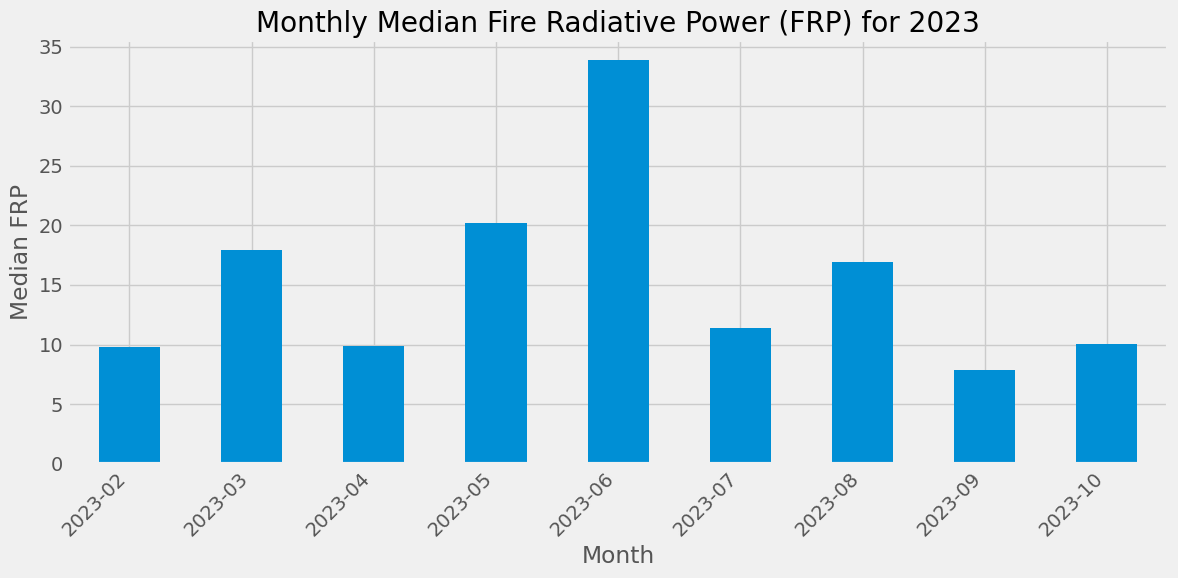

In [449]:
# TODO: Change year
year = 2023

 # Bar graph for the year
plot_frp_by_timeframe(df, year)

Code Block 2C

In [450]:
def plot_intense_fires_folium(df, year, month=None):
    """
    Generates an interactive map showing the locations of intense fires (FRP >= 100)
    for a specific year and optional month using Folium, with color scaling by intensity
    and a legend.

    Args:
        df (pd.DataFrame): The input DataFrame with a datetime index and
                           'latitude', 'longitude', and 'frp' columns.
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). Defaults to None.
    """
    if month is not None:
        df_filtered = df[(df.index.year == year) & (df.index.month == month)].copy()
        timeframe_str = f"Intense Fires for {month}/{year}"
    else:
        df_filtered = df[df.index.year == year].copy()
        timeframe_str = f"Intense Fires for {year}"

    # Filter for intense fires (FRP >= 100)
    intense_fires_df = df_filtered[df_filtered['frp'] >= 100].copy()

    if intense_fires_df.empty:
        print(f"No intense fires found for {timeframe_str}")
        return

    # Create a base map of Sweden
    m = folium.Map(location=[16, 62], zoom_start=4)

    # Add markers for intense fire locations
    max_frp = intense_fires_df['frp'].max()
    min_frp = intense_fires_df['frp'].min()

    # Create a colormap for FRP values
    cmap = plt.cm.get_cmap('YlOrRd') # Yellow to Red colormap
    norm = mcolors.Normalize(vmin=min_frp, vmax=max_frp)

    for index, row in intense_fires_df.iterrows():
        # Scale FRP to a reasonable range for radius (e.g., 2 to 15)
        radius = 2 + (row['frp'] - min_frp) / (max_frp - min_frp) * 13 if max_frp > min_frp else 5
        # Scale FRP to a reasonable range for opacity (e.g., 0.4 to 0.9)
        opacity = 0.4 + (row['frp'] - min_frp) / (max_frp - min_frp) * 0.5 if max_frp > min_frp else 0.7

        # Get color from colormap based on FRP value
        color = mcolors.to_hex(cmap(norm(row['frp'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"FRP: {row['frp']:.2f}"
        ).add_to(m)

    # Add a legend
    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[0, 250, 500],   # evenly spaced points in the range
        vmin=0,
        vmax=500
    )

    # Add the colormap as a legend to the map
    colormap.caption = 'Fire Radiative Power (FRP)'
    colormap.add_to(m)

    # Display the map
    display(m)

In [451]:
# TODO: Change year and month
year = 2024
month = 7

# specific month
#plot_intense_fires_folium(df, year, month)

# only year
plot_intense_fires_folium(df, year)

# Preprocessing

Code Block 3A

In [452]:
# List of column names that we don't need for our analysis
columns_to_drop = ['acq_time', 'satellite', 'instrument', 'version', 'daynight']

# Remove the specified columns from the DataFrame "df"
# inplace=True means the change is applied directly to df without creating a new DataFrame
df.drop(columns=columns_to_drop, inplace=True)

# Display the first 5 rows of the updated DataFrame to confirm the columns were removed
df.head()

,latitude,longitude,brightness,scan,track,confidence,bright_t31,frp,type
acq_date,,,,,,,,,
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,54,274.3,16.0,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,54,274.3,16.0,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,54,274.3,16.0,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,54,274.3,16.0,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,54,274.3,16.0,2


Code Block 3B

In [453]:
# Define a bounding box that covers Sweden, Norway, Denmark, Finland and the Baltics
# You can adjust these values if you need a slightly smaller/larger area
min_latitude, max_latitude = 52.0, 72.0
min_longitude, max_longitude = -10.0, 40.0

# Ensure min values are less than max values (in case they were accidentally reversed)
if min_latitude > max_latitude:
    min_latitude, max_latitude = max_latitude, min_latitude
if min_longitude > max_longitude:
    min_longitude, max_longitude = max_longitude, min_longitude

# Drop rows with missing coordinates before filtering (these cannot be spatially filtered)
rows_before = len(df)
rows_with_coords = len(df.dropna(subset=['latitude', 'longitude']))
print(f"Total rows in dataset: {rows_before}")
print(f"Rows with non-missing coordinates: {rows_with_coords}")

# Apply the bounding-box filter
df_filtered = df.dropna(subset=['latitude', 'longitude']).copy()
df_filtered = df_filtered[(df_filtered['latitude'] >= min_latitude) & (df_filtered['latitude'] <= max_latitude) &
                          (df_filtered['longitude'] >= min_longitude) & (df_filtered['longitude'] <= max_longitude)]

print(f"Number of rows after spatial filtering: {len(df_filtered)}")
if len(df_filtered) > 0:
    print(f"Filtered date range: {df_filtered.index.min()} to {df_filtered.index.max()}")
else:
    print("Warning: no rows found after spatial filtering. Check bounding box or coordinate columns.")

Total rows in dataset: 71180
Rows with non-missing coordinates: 71180
Number of rows after spatial filtering: 71180
Filtered date range: 2019-01-05 00:00:00 to 2024-12-11 00:00:00


Code Block 3C

In [454]:
# Create a map centered around the area
m = folium.Map(location=[(min_latitude + max_latitude) / 2, (min_longitude + max_longitude) / 2], zoom_start=6)

# Add a rectangle representing the boundaries
folium.Rectangle(
    bounds=[(min_latitude, min_longitude), (max_latitude, max_longitude)],
    color='#ff7800',
    weight=2,
    fill=True,
    fill_color='#ffff00',
    fill_opacity=0.2
).add_to(m)

# Display the map
display(m)

Code Block 3D

In [455]:
# IMPORTANT: Save the raw filtered data before aggregation for later visualization
df_filtered_raw = df_filtered.copy()

# Store latitude and longitude info before aggregation (we'll need this for mapping later)
# For each day, keep the median lat/lon of all fires that occurred
df_locations = df_filtered.resample('D')[['latitude', 'longitude']].median()

# Aggregate by daily - sum the FRP for all fires on each day
# This way we preserve the actual fire activity per day
df = df_filtered.resample('D')['frp'].sum().to_frame()

# Merge the location data back
df = df.join(df_locations)

# Only keep days where there were actually fires (FRP > 0)
# This prevents the model from learning that fires happen every single day
df = df[df['frp'] > 0]

print(f"Number of days with fire activity: {len(df)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Original individual fire records preserved: {len(df_filtered_raw)}")

# Display the dataset
df.head()

Number of days with fire activity: 856
Date range: 2019-01-05 00:00:00 to 2024-12-11 00:00:00
Original individual fire records preserved: 71180


,frp,latitude,longitude
acq_date,,,
2019-01-05,320.0,58.3396,11.4248
2019-02-25,308.0,64.6687,21.2947
2019-02-27,232.0,57.7319,12.9433
2019-03-22,198.0,58.3635,12.3863
2019-03-23,536.0,54.5650,24.8453


# Visualizing Region Data

Code Block 4A

Text(0, 0.5, 'FRP')

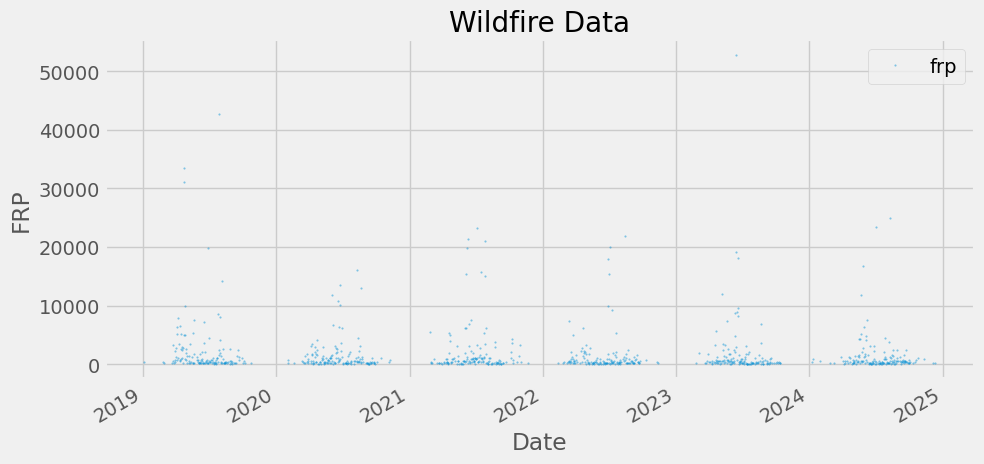

In [456]:
# Get the default seaborn color palette (list of colors to use in plots)
color_pal = sns.color_palette()

# Plot the 'frp' column from the DataFrame
df.plot(
    style='.',                # Plot style: '.' means scatter-style points
    y='frp',                  # Column to plot on the y-axis
    figsize=(10, 5),          # Set the figure size (width=10, height=5)
    ms=1,                     # Marker size (small points since the dataset may be large)
    color=color_pal[0],       # Use the first color from the seaborn palette
    title='Wildfire Data',    # Title for the plot
    alpha=0.5                 # Set transparency (helps reduce overplotting)
)

# Label the x-axis and y-axis
plt.xlabel('Date')            # X-axis label: dates (time series)
plt.ylabel('FRP')             # Y-axis label: Fire Radiative Power

Code Block 4B

In [457]:
def create_features(df):
    """
    Creates time series features from datetime index and concatenates to original df.
    """
    df = df.copy()
    df['date'] = df.index
    df['month'] = df['date'].dt.month
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300],
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    df = df.drop(columns=['date', 'date_offset']) # Drop temporary columns

    return df

df_features = create_features(df)
X = df_features.drop(columns=['frp'])
y = df_features['frp']

Code Block 4C

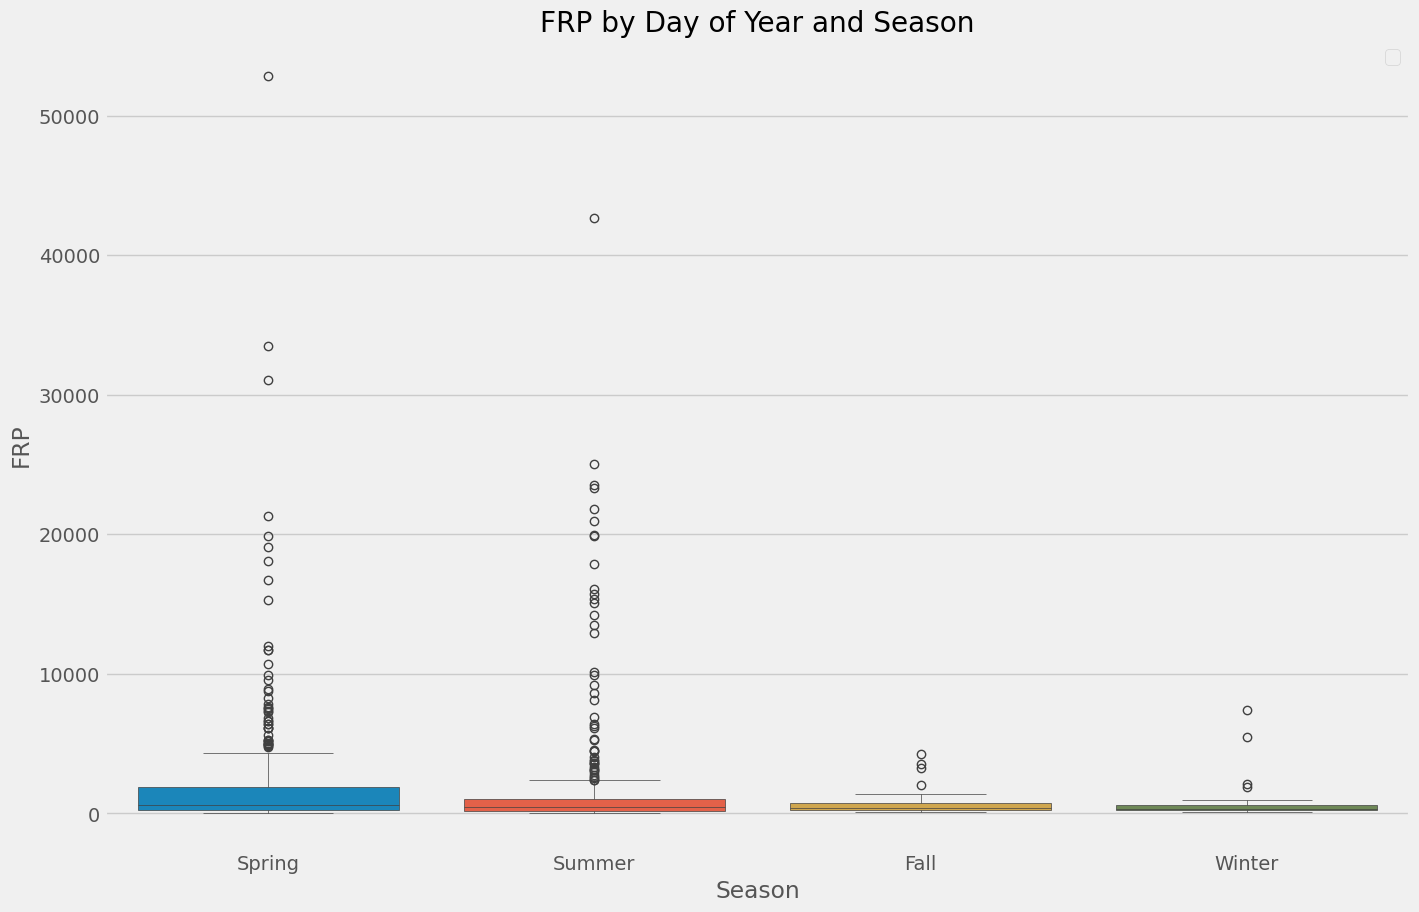

In [458]:
fig, ax = plt.subplots(figsize=(15, 10)) # Increased figure size
sns.boxplot(data=df_features.dropna(),
            x='season',
            y='frp',
            hue='season',
            ax=ax,
            linewidth=0.5) # Slightly reduced linewidth
ax.set_title('FRP by Day of Year and Season')
ax.set_xlabel('Season')
ax.set_ylabel('FRP')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

# Splitting Data into Train and Test

Code Block 5A

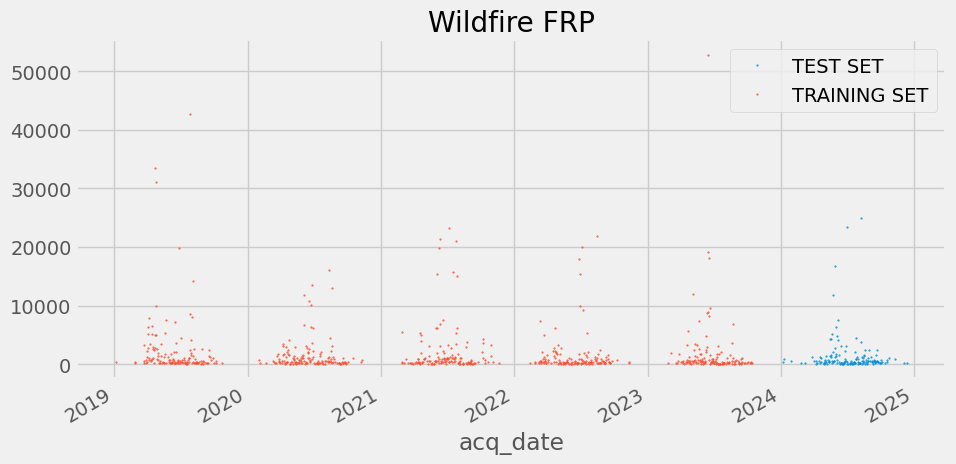

In [459]:
# TODO: Change date
split_date = '1-Jan-2024'
df_train = df_features.loc[df_features.index <= split_date].copy()
df_test = df_features.loc[df_features.index > split_date].copy()

# Plot train and test so you can see where we have split
pd.concat([df_test.groupby(df_test.index)['frp'].mean().rename('TEST SET'),
           df_train.groupby(df_train.index)['frp'].mean().rename('TRAINING SET')],
          axis=1) \
    .plot(figsize=(10, 5), title='Wildfire FRP', style='.', ms=1)
plt.show()

# Training the Model

Code Block 6A

In [460]:
# Format data for prophet model using ds and y
df_train_prophet = df_train.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

Code Block 6B

In [461]:
%%time
# Initialize and train the Prophet model
# The Prophet model is a time series forecasting model developed by Facebook
model = Prophet()
# Fit the model to the training data
# This step can take some time as the model learns the patterns in the data
model.fit(df_train_prophet)

22:13:20 - cmdstanpy - INFO - Chain [1] start processing
22:13:20 - cmdstanpy - INFO - Chain [1] done processing
22:13:20 - cmdstanpy - INFO - Chain [1] done processing


CPU times: user 64.5 ms, sys: 2.97 ms, total: 67.5 ms
Wall time: 95.2 ms


# Evaluating the Model

Code Block 7A

In [462]:
# Predict on test set with model
df_test_prophet = df_test.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

# Use the trained Prophet model to make predictions on the test data
df_test_fcst = model.predict(df_test_prophet)

Code Block 7B

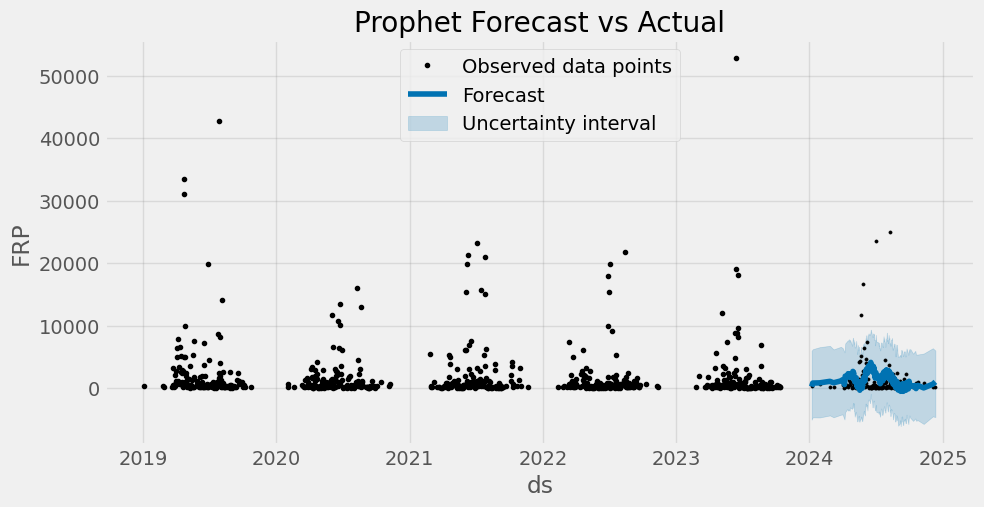

In [463]:
# Create a figure and axis for plotting, setting the figure size
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the Prophet forecast results on the specified axis
fig = model.plot(df_test_fcst, ax=ax)

# Plot the actual values from the test set as scatter points
ax.scatter(df_test_prophet['ds'], df_test_prophet['y'], color='black', s=5)

# Set the plot title
ax.set_title('Prophet Forecast vs Actual')
yaxis = ax.get_yaxis()
yaxis.set_label_text('FRP')

# Add a legend to differentiate between forecast and actual values
ax.legend()

# Display the plot
plt.show()

Code Block 7C

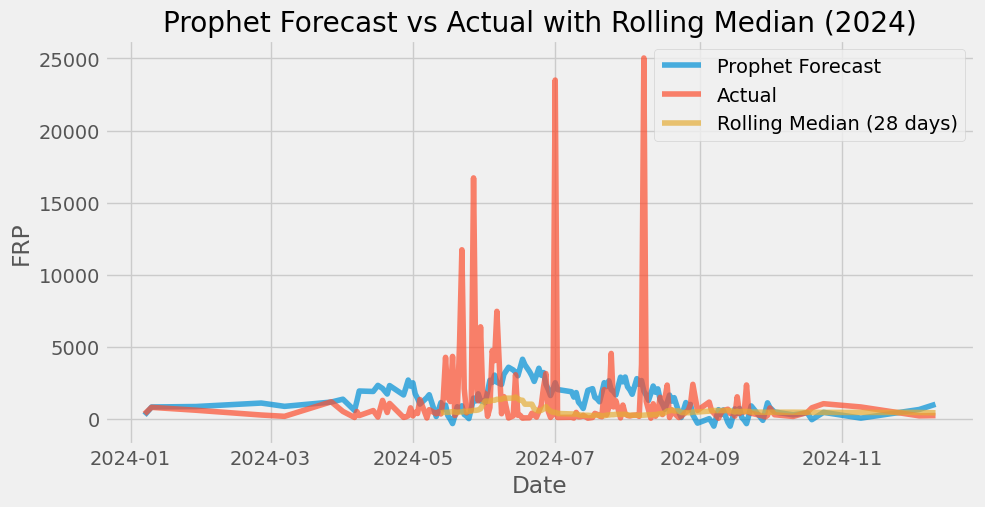

In [464]:
# Make a graph to compare prediction to actual values with rolling median for the test set
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_test_fcst['ds'], df_test_fcst['yhat'], label='Prophet Forecast', alpha=0.7)
ax.plot(df_test_prophet['ds'], df_test_prophet['y'], label='Actual', alpha=0.7)

# TODO: You can adjust the window size
rolling_window = 28

# Calculate and plot rolling median
df_test_prophet['rolling_avg'] = df_test_prophet['y'].rolling(window=rolling_window).median()
ax.plot(df_test_prophet['ds'], df_test_prophet['rolling_avg'], label=f'Rolling Median ({rolling_window} days)', alpha=0.7)

ax.set_title('Prophet Forecast vs Actual with Rolling Median (2024)')
ax.set_xlabel('Date')
ax.set_ylabel('FRP')
ax.legend()
plt.show()

Code Block 7D

In [465]:
# Calculate MAE
mae = mean_absolute_error(df_test['frp'], df_test_fcst['yhat'])
print('MAE:', mae)

MAE: 1743.8311055604458


Code Block 7E

In [466]:
# Calculate additional metrics for better evaluation
from sklearn.metrics import mean_squared_error, r2_score

# RMSE (Root Mean Squared Error) - penalizes larger errors more than MAE
rmse = np.sqrt(mean_squared_error(df_test['frp'], df_test_fcst['yhat']))
print(f'RMSE: {rmse:.2f}')

# R² Score - measures how well the model explains the variance (1.0 = perfect, 0 = baseline)
r2 = r2_score(df_test['frp'], df_test_fcst['yhat'])
print(f'R² Score: {r2:.4f}')

# MAPE can be misleading when actual values are small
# Only calculate for days where actual FRP > 100 (to avoid division by very small numbers)
high_frp_indices = df_test[df_test['frp'] > 100].index
if len(high_frp_indices) > 0:
    # Get the matching rows from both dataframes using the date index
    actual_high = df_test.loc[high_frp_indices, 'frp']
    # Match predictions by aligning on the 'ds' column from df_test_fcst
    df_test_fcst_indexed = df_test_fcst.set_index('ds')
    pred_high = df_test_fcst_indexed.loc[high_frp_indices, 'yhat']
    
    mape_filtered = mean_absolute_percentage_error(actual_high, pred_high)
    print(f'MAPE (for FRP > 100): {mape_filtered:.2f}%')
    print(f'Number of high-FRP days: {len(high_frp_indices)}')
else:
    print('No days with FRP > 100 in test set')

# Show some context
print(f'\nTest set FRP range: {df_test["frp"].min():.2f} to {df_test["frp"].max():.2f}')
print(f'Test set FRP mean: {df_test["frp"].mean():.2f}')
print(f'Test set FRP median: {df_test["frp"].median():.2f}')

RMSE: 3402.80
R² Score: -0.0580
MAPE (for FRP > 100): 322.38%
Number of high-FRP days: 136

Test set FRP range: 44.00 to 25030.00
Test set FRP mean: 1380.34
Test set FRP median: 454.00


Code Block 7F

In [467]:
def plot_prophet_predictions_folium(df_fcst, year, month=None):
    """
    Generates an interactive map showing the locations of Prophet model predictions
    for a specific year and optional month using Folium, with color scaling by predicted FRP.

    Args:
        df_fcst (pd.DataFrame): The input DataFrame with 'ds', 'yhat', 'latitude',
                                'longitude' columns (from Prophet forecast and original data).
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). Defaults to None.
    """
    # Ensure 'ds' is datetime and set as index for filtering
    df_fcst['ds'] = pd.to_datetime(df_fcst['ds'])
    df_fcst.set_index('ds', inplace=True)

    if month is not None:
        df_filtered = df_fcst[(df_fcst.index.year == year) & (df_fcst.index.month == month)].copy()
        timeframe_str = f"Prophet Predictions for {month}/{year}"
    else:
        df_filtered = df_fcst[df_fcst.index.year == year].copy()
        timeframe_str = f"Prophet Predictions for {year}"

    # Drop rows with NaN in latitude or longitude
    df_filtered.dropna(subset=['latitude', 'longitude'], inplace=True)

    if df_filtered.empty:
        print(f"No predictions with location data found for {timeframe_str}")
        return

    # Create a base map of the US
    m = folium.Map(location=[16, 62], zoom_start=4)

    # Add markers for predicted fire locations
    # Use 'yhat' for coloring and radius
    max_yhat = df_filtered['yhat'].max()
    min_yhat = df_filtered['yhat'].min()

    # Create a colormap for yhat values
    cmap = plt.cm.get_cmap('YlOrRd') # Yellow to Red colormap
    norm = mcolors.Normalize(vmin=min_yhat, vmax=max_yhat)

    for index, row in df_filtered.iterrows():
        # Scale yhat to a reasonable range for radius (e.g., 2 to 15)
        radius = 2 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 13 if max_yhat > min_yhat else 5
        # Scale yhat to a reasonable range for opacity (e.g., 0.4 to 0.9)
        opacity = 0.4 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 0.5 if max_yhat > min_yhat else 0.7

        # Get color from colormap based on yhat value
        color = mcolors.to_hex(cmap(norm(row['yhat'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"Predicted FRP: {row['yhat']:.2f}"
        ).add_to(m)


      # Add a legend
    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[0, 250, 500],   # evenly spaced points in the range
        vmin=0,
        vmax=500
    )

    # Add the colormap as a legend to the map
    colormap.caption = 'Fire Radiative Power (FRP)'
    colormap.add_to(m)

    # Display the map
    display(m)

Code Block 7G

In [468]:
# TODO: Change year and month
year = 2024
month = 7

# IMPORTANT NOTE: Prophet predicts DAILY FRP TOTALS for the region, not individual fires!
# Each point on the map represents the predicted FRP for ONE DAY, not one fire.
# The lat/lon are median locations from training data, not actual fire locations.

# Merge latitude and longitude from df_test_prophet into df_test_fcst
df_test_fcst_merged = df_test_fcst.merge(df_test_prophet[['ds', 'latitude', 'longitude']], on='ds', how='left')

# Compare prediction days vs actual fire events
pred_days = len(df_test_fcst_merged[(pd.to_datetime(df_test_fcst_merged['ds']).dt.year == year) & 
                                     (pd.to_datetime(df_test_fcst_merged['ds']).dt.month == month)])
actual_fires = len(df_filtered_raw[(df_filtered_raw.index.year == year) & 
                                    (df_filtered_raw.index.month == month)])

print(f"Prophet predictions for {month}/{year}: {pred_days} days")
print(f"Actual individual fire events in {month}/{year}: {actual_fires}")
print("\nNote: Each prediction marker = FRP for one day (not one fire)")
print("Prophet models daily fire activity, not individual fire locations!\n")

# Plot predictions (each marker = one day's predicted FRP)
plot_prophet_predictions_folium(df_test_fcst_merged, year, month)

# only yeardf_test_fcst_merged
#plot_prophet_predictions_folium(df_test_fcst_merged, year)

# print predictions with locations
#df_test_fcst_merged.head()

# print ALL predictions with locations


Prophet predictions for 7/2024: 23 days
Actual individual fire events in 7/2024: 1240

Note: Each prediction marker = FRP for one day (not one fire)
Prophet models daily fire activity, not individual fire locations!



In [469]:
# Create a better comparison: Daily FRP predictions vs actual
year = 2024
month = 7

# Get actual fires for the month from raw data
actual_month = df_filtered_raw[(df_filtered_raw.index.year == year) & 
                                (df_filtered_raw.index.month == month)].copy()

# Get predictions for the month (reset index first in case it was modified)
pred_month = df_test_fcst.merge(df_test_prophet[['ds', 'latitude', 'longitude']], on='ds', how='left').copy()
pred_month['ds'] = pd.to_datetime(pred_month['ds'])
pred_month = pred_month[(pred_month['ds'].dt.year == year) & 
                        (pred_month['ds'].dt.month == month)]

# Aggregate actual fires by day for fair comparison
actual_daily = actual_month.resample('D')['frp'].agg(['sum', 'count'])
actual_daily = actual_daily[actual_daily['sum'] > 0]  # Only days with fires

print(f"{'='*60}")
print(f"COMPARISON FOR {month}/{year}")
print(f"{'='*60}\n")

print(f"ACTUAL DATA:")
print(f"  - Days with fire activity: {len(actual_daily)}")
print(f"  - Total individual fire detections: {actual_month.shape[0]}")
print(f"  - Total FRP: {actual_month['frp'].sum():.2f}")
if len(actual_daily) > 0:
    print(f"  - Average FRP per day with fires: {actual_daily['sum'].mean():.2f}\n")
else:
    print(f"  - No fires detected in this period\n")

print(f"PROPHET PREDICTIONS:")
print(f"  - Days predicted: {len(pred_month)}")
print(f"  - Total predicted FRP: {pred_month['yhat'].sum():.2f}")
if len(pred_month) > 0:
    print(f"  - Average predicted FRP per day: {pred_month['yhat'].mean():.2f}\n")
else:
    print(f"  - No predictions for this period\n")

print(f"KEY INSIGHT:")
print(f"  Prophet predicts daily FRP totals ({len(pred_month)} days),")
print(f"  not individual fire locations ({actual_month.shape[0]} fires).")
if len(pred_month) > 0 and actual_month.shape[0] > 0:
    print(f"  The map shows {len(pred_month)} markers (days), not {actual_month.shape[0]} fires.")
    
    # Additional comparison
    if len(actual_daily) > 0:
        print(f"\n  Prediction vs Reality:")
        print(f"    - Model expected ~{pred_month['yhat'].mean():.2f} FRP per day")
        print(f"    - Actual average was {actual_daily['sum'].mean():.2f} FRP per day with fires")
        print(f"    - 2024 had {len(actual_daily)} active fire days vs {len(pred_month)} days predicted")

COMPARISON FOR 7/2024

ACTUAL DATA:
  - Days with fire activity: 23
  - Total individual fire detections: 1240
  - Total FRP: 37050.00
  - Average FRP per day with fires: 1610.87

PROPHET PREDICTIONS:
  - Days predicted: 23
  - Total predicted FRP: 43915.15
  - Average predicted FRP per day: 1909.35

KEY INSIGHT:
  Prophet predicts daily FRP totals (23 days),
  not individual fire locations (1240 fires).
  The map shows 23 markers (days), not 1240 fires.

  Prediction vs Reality:
    - Model expected ~1909.35 FRP per day
    - Actual average was 1610.87 FRP per day with fires
    - 2024 had 23 active fire days vs 23 days predicted


Code Block 7H

In [470]:
# TODO: Change year and month
year = 2024
month = 7

# Plot actual fires using the RAW filtered data (individual fire records)
# NOT the aggregated df (which has daily sums with median locations)
plot_intense_fires_folium(df_filtered_raw, year, month)